# 🎯 Hey M — Model Evaluation Notebook

Tests the TFLite cascade models (`stage1_fp16.tflite` + `stage2_fp16.tflite`) against real recordings from Google Drive.

**Drive folder expected layout:**
```
wakeword_data/
  positive/   ← 'Hey M' recordings (.wav / .mp3 / .m4a)
  negative/   ← non-wake-word recordings
```

**Metrics produced:**
- Per-sample Stage1 + Stage2 scores
- Precision / Recall / F1 at multiple Stage2 thresholds
- PR curve
- Confusion matrix
- Per-file score CSV export

In [1]:
%%capture
!pip install librosa soundfile tqdm --quiet
!apt-get install -y ffmpeg > /dev/null 2>&1
print('✅ Dependencies ready')

In [2]:
# ─── Mount Google Drive ────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print('✅ Drive mounted')

Mounted at /content/drive
✅ Drive mounted


In [3]:
# ══════════════════════════════════════════════════════════════════════
#  ⚙️  CONFIG  — edit these paths to match your Drive layout
# ══════════════════════════════════════════════════════════════════════

# Root folder on Drive containing positive/ and negative/ subfolders
DRIVE_DATA_DIR    = '/content/drive/MyDrive/wakeword_data'

# Folder on Drive (or local) that holds the .tflite model files
# Leave as None to auto-search Drive for stage1_fp16.tflite
DRIVE_MODEL_DIR   = '/content/drive/MyDrive/wakeword_checkpoint'

# ── Cascade thresholds (must match Android TFLiteWakeWordDetector constants) ──
STAGE1_THRESHOLD           = 0.35   # Windows below this skip Stage2
STAGE2_THRESHOLD           = 0.35   # Per-window bar
STAGE2_CONSECUTIVE_REQUIRED = 2     # Consecutive windows needed to confirm

# ── Audio / mel parameters (must match training notebook exactly) ──
SAMPLE_RATE    = 16000
DURATION       = 1.0          # seconds
FRAME_LENGTH   = int(SAMPLE_RATE * DURATION)   # 16000
N_MELS         = 40
N_FFT          = 512
HOP_LENGTH     = 160
FMIN           = 80.0
FMAX           = 7600.0
TOP_DB         = 80.0         # librosa.power_to_db top_db default
EXPECTED_FRAMES = 97          # 1 + (16000 - 512) // 160

# ── Sliding-window inference (for recordings > 1 second) ──
STRIDE_SAMPLES = 8000         # 500 ms stride → 50 % overlap

print('✅ Config set')

✅ Config set


In [4]:
import os, glob, warnings
from pathlib import Path
import numpy as np
import librosa
import soundfile as sf
import tensorflow as tf
from tqdm.auto import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
warnings.filterwarnings('ignore')

print(f'TFLite runtime: {tf.__version__}')

TFLite runtime: 2.20.0


In [5]:
# ─── Locate model files ────────────────────────────────────────────────────────
def find_model(name, search_roots):
    for root in search_roots:
        for p in Path(root).rglob(name):
            return str(p)
    return None

search_roots = [DRIVE_MODEL_DIR, '/content/drive/MyDrive', '/content']
STAGE1_PATH = find_model('stage1_fp16.tflite', search_roots)
STAGE2_PATH = find_model('stage2_fp16.tflite', search_roots)

assert STAGE1_PATH, '❌ stage1_fp16.tflite not found — check DRIVE_MODEL_DIR'
assert STAGE2_PATH, '❌ stage2_fp16.tflite not found — check DRIVE_MODEL_DIR'

print(f'Stage1 → {STAGE1_PATH}')
print(f'Stage2 → {STAGE2_PATH}')

Stage1 → /content/drive/MyDrive/wakeword_checkpoint/stage1_fp16.tflite
Stage2 → /content/drive/MyDrive/wakeword_checkpoint/stage2_fp16.tflite


In [6]:
# ─── Load TFLite interpreters ─────────────────────────────────────────────────
def load_interpreter(path):
    interp = tf.lite.Interpreter(model_path=path)
    interp.allocate_tensors()
    inp  = interp.get_input_details()[0]
    out  = interp.get_output_details()[0]
    print(f'  {Path(path).name}  input={inp["shape"]}  dtype={inp["dtype"].__name__}  output={out["shape"]}')
    return interp, inp, out

print('Loading models...')
s1_interp, s1_inp, s1_out = load_interpreter(STAGE1_PATH)
s2_interp, s2_inp, s2_out = load_interpreter(STAGE2_PATH)
print('✅ Models loaded')

Loading models...
  stage1_fp16.tflite  input=[ 1 40 97  1]  dtype=float32  output=[1 1]
  stage2_fp16.tflite  input=[ 1 40 97  1]  dtype=float32  output=[1 1]
✅ Models loaded


In [7]:
# ─── Mel-spectrogram extractor ────────────────────────────────────────────────
# Matches the training notebook exactly:
#   - librosa STFT with center=False
#   - power_to_db(ref=np.max, top_db=80)   ← TOP_DB=80 clipping
#   - per-instance min-max normalisation
#   - norm='slaney' triangular filterbank  ← librosa default since 0.8

def audio_to_mel(audio: np.ndarray) -> np.ndarray:
    """Convert 16kHz mono float32 array to normalised mel tensor [1,40,97,1]."""
    # STFT → mel power
    stft   = np.abs(librosa.stft(audio, n_fft=N_FFT, hop_length=HOP_LENGTH, center=False)) ** 2
    mel_pw = librosa.feature.melspectrogram(
        S=stft, sr=SAMPLE_RATE, n_mels=N_MELS, fmin=FMIN, fmax=FMAX, norm='slaney'
    )
    # Convert to dB, ref=max, clip floor at -TOP_DB
    mel_db = librosa.power_to_db(mel_pw, ref=np.max, top_db=TOP_DB)
    # Per-instance min-max normalisation → [0, 1]
    lo, hi = mel_db.min(), mel_db.max()
    mel_n  = (mel_db - lo) / (hi - lo + 1e-6)
    # Crop or pad time axis to EXPECTED_FRAMES
    T = mel_n.shape[1]
    if T < EXPECTED_FRAMES:
        mel_n = np.pad(mel_n, ((0,0),(0, EXPECTED_FRAMES - T)))
    elif T > EXPECTED_FRAMES:
        mel_n = mel_n[:, :EXPECTED_FRAMES]
    # [40,97] → [1,40,97,1]
    return mel_n[np.newaxis, :, :, np.newaxis].astype(np.float32)


def run_tflite(interp, inp_details, out_details, tensor: np.ndarray) -> float:
    interp.set_tensor(inp_details['index'], tensor)
    interp.invoke()
    raw = interp.get_tensor(out_details['index'])
    return float(raw.flatten()[0])


def infer_window(audio_window: np.ndarray):
    """Run cascade on a single 1-second audio window. Returns (s1, s2)."""
    mel = audio_to_mel(audio_window)
    s1  = run_tflite(s1_interp, s1_inp, s1_out, mel)
    if s1 < STAGE1_THRESHOLD:
        return s1, 0.0   # Stage2 skipped
    s2 = run_tflite(s2_interp, s2_inp, s2_out, mel)
    return s1, s2


def infer_file(filepath: str):
    """
    Sliding-window inference over a whole audio file.
    Returns:
        windows: list of dicts with {start_s, s1, s2, rms}
        detected: bool — True if consecutive voting is satisfied
        max_s2:   float — highest Stage2 score across all windows
    """
    try:
        audio, _ = librosa.load(filepath, sr=SAMPLE_RATE, mono=True)
    except Exception as e:
        return [], False, 0.0

    windows = []
    consecutive = 0
    detected = False

    for start in range(0, max(1, len(audio) - FRAME_LENGTH + 1), STRIDE_SAMPLES):
        chunk = audio[start : start + FRAME_LENGTH]
        if len(chunk) < FRAME_LENGTH:
            chunk = np.pad(chunk, (0, FRAME_LENGTH - len(chunk)))
        rms = float(np.sqrt(np.mean(chunk ** 2)))
        s1, s2 = infer_window(chunk)
        windows.append({'start_s': start / SAMPLE_RATE, 's1': s1, 's2': s2, 'rms': rms})
        if s2 >= STAGE2_THRESHOLD:
            consecutive += 1
            if consecutive >= STAGE2_CONSECUTIVE_REQUIRED:
                detected = True
        else:
            consecutive = 0

    max_s2 = max((w['s2'] for w in windows), default=0.0)
    return windows, detected, max_s2

print('✅ Inference helpers defined')

✅ Inference helpers defined


In [8]:
# ─── Collect audio files from Drive ───────────────────────────────────────────
SUPPORTED = {'.wav', '.mp3', '.m4a', '.ogg', '.flac', '.webm', '.aac', '.wma'}

def collect_files(folder):
    folder = Path(folder)
    if not folder.exists():
        print(f'  ⚠️  Folder not found: {folder}')
        return []
    return sorted([str(p) for p in folder.rglob('*') if p.suffix.lower() in SUPPORTED])

pos_files = collect_files(Path(DRIVE_DATA_DIR) / 'positive')
neg_files = collect_files(Path(DRIVE_DATA_DIR) / 'negative')

print(f'Positives : {len(pos_files)} files')
print(f'Negatives : {len(neg_files)} files')
assert pos_files or neg_files, '❌ No audio files found — check DRIVE_DATA_DIR'

# Preview first few
for f in pos_files[:3]: print(' +', Path(f).name)
for f in neg_files[:3]: print(' -', Path(f).name)

Positives : 8 files
Negatives : 4 files
 + WhatsApp Ptt 2026-06-01 at 8.24.12 AM.ogg
 + WhatsApp Ptt 2026-06-02 at 12.58.04 PM.ogg
 + WhatsApp Ptt 2026-06-02 at 12.58.08 PM (1).ogg
 - WhatsApp Ptt 2026-06-02 at 1.00.01 PM.ogg
 - WhatsApp Ptt 2026-06-02 at 1.00.04 PM.ogg
 - WhatsApp Ptt 2026-06-02 at 1.00.07 PM.ogg


In [9]:
# ─── Run inference on all files ────────────────────────────────────────────────
rows = []

def run_set(files, label):
    for f in tqdm(files, desc=f'  {label}', leave=True):
        wins, det, max_s2 = infer_file(f)
        if not wins:
            continue
        max_s1 = max(w['s1'] for w in wins)
        mean_s2 = float(np.mean([w['s2'] for w in wins if w['s1'] >= STAGE1_THRESHOLD] or [0.0]))
        rows.append({
            'file'     : Path(f).name,
            'label'    : label,
            'detected' : int(det),
            'max_s1'   : round(max_s1, 4),
            'max_s2'   : round(max_s2, 4),
            'mean_s2'  : round(mean_s2, 4),
            'n_windows': len(wins),
        })

run_set(pos_files, 'positive')
run_set(neg_files, 'negative')

df = pd.DataFrame(rows)
print(f'\nTotal evaluated: {len(df)} files')
df.head(10)

  positive:   0%|          | 0/8 [00:00<?, ?it/s]

  negative:   0%|          | 0/4 [00:00<?, ?it/s]


Total evaluated: 12 files


,file,label,detected,max_s1,max_s2,mean_s2,n_windows
0,WhatsApp Ptt 2026-06-01 at 8.24.12 AM.ogg,positive,1,0.7734,0.6361,0.5460,40
1,WhatsApp Ptt 2026-06-02 at 12.58.04 PM.ogg,positive,0,0.7228,0.5195,0.5195,1
2,WhatsApp Ptt 2026-06-02 at 12.58.08 PM (1).ogg,positive,1,0.7105,0.6084,0.5159,3
3,WhatsApp Ptt 2026-06-02 at 12.58.08 PM.ogg,positive,1,0.7105,0.6084,0.5159,3
4,WhatsApp Ptt 2026-06-02 at 12.58.11 PM.ogg,positive,0,0.7090,0.6313,0.6313,1
5,WhatsApp Ptt 2026-06-02 at 12.58.19 PM.ogg,positive,0,0.7219,0.5977,0.5977,1
6,WhatsApp Ptt 2026-06-02 at 12.58.28 PM.ogg,positive,1,0.7362,0.6675,0.6297,2
7,WhatsApp Ptt 2026-06-02 at 12.58.32 PM.ogg,positive,0,0.7214,0.6007,0.6007,1
8,WhatsApp Ptt 2026-06-02 at 1.00.01 PM.ogg,negative,0,0.5933,0.5323,0.5323,1
9,WhatsApp Ptt 2026-06-02 at 1.00.04 PM.ogg,negative,1,0.7456,0.6205,0.5942,2


In [10]:
# ─── Summary stats ─────────────────────────────────────────────────────────────
y_true = (df['label'] == 'positive').astype(int).values
s2_scores = df['max_s2'].values

pos_df = df[df['label'] == 'positive']
neg_df = df[df['label'] == 'negative']

print('── Stage2 score distribution ─────────────────────────────')
print(f"Positives  mean={pos_df['max_s2'].mean():.3f}  median={pos_df['max_s2'].median():.3f}  "
      f"min={pos_df['max_s2'].min():.3f}  max={pos_df['max_s2'].max():.3f}")
print(f"Negatives  mean={neg_df['max_s2'].mean():.3f}  median={neg_df['max_s2'].median():.3f}  "
      f"min={neg_df['max_s2'].min():.3f}  max={neg_df['max_s2'].max():.3f}")

print('\n── Detection results at current thresholds ───────────────')
print(f"S1≥{STAGE1_THRESHOLD}  S2≥{STAGE2_THRESHOLD}  consecutive≥{STAGE2_CONSECUTIVE_REQUIRED}")
tp = int((pos_df['detected'] == 1).sum())
fn = int((pos_df['detected'] == 0).sum())
fp = int((neg_df['detected'] == 1).sum())
tn = int((neg_df['detected'] == 0).sum())

recall    = tp / (tp + fn + 1e-9)
precision = tp / (tp + fp + 1e-9)
f1        = 2 * precision * recall / (precision + recall + 1e-9)

print(f'TP={tp}  FN={fn}  FP={fp}  TN={tn}')
print(f'Recall   = {recall:.3f}  (wake-word catch rate)')
print(f'Precision= {precision:.3f}  (how often a trigger is real)')
print(f'F1       = {f1:.3f}')

── Stage2 score distribution ─────────────────────────────
Positives  mean=0.609  median=0.608  min=0.519  max=0.667
Negatives  mean=0.577  median=0.577  min=0.532  max=0.621

── Detection results at current thresholds ───────────────
S1≥0.35  S2≥0.35  consecutive≥2
TP=4  FN=4  FP=2  TN=2
Recall   = 0.500  (wake-word catch rate)
Precision= 0.667  (how often a trigger is real)
F1       = 0.571


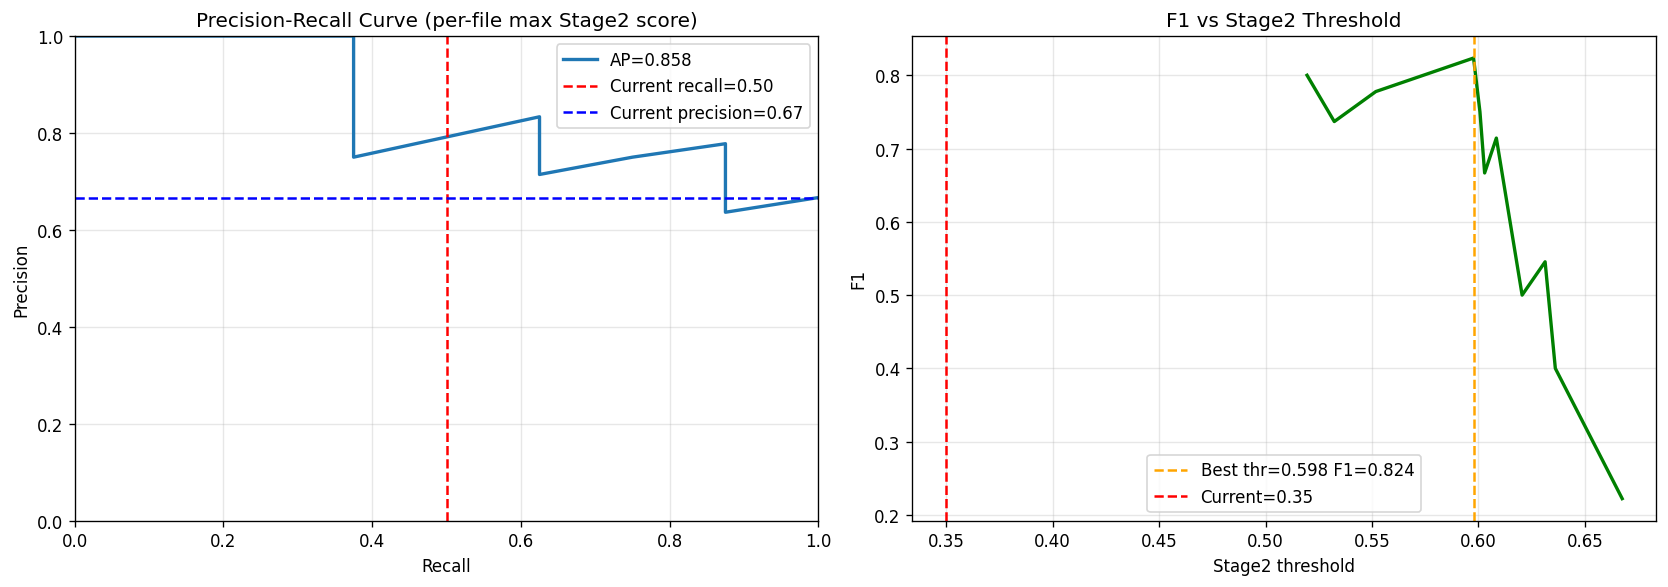


🎯 Best single-window threshold: 0.598  (F1=0.824)
   Current STAGE2_THRESHOLD=0.35


In [11]:
# ─── Sweep Stage2 thresholds ───────────────────────────────────────────────────
# (uses max_s2 per file as decision score, consecutive=1 for sweep simplicity)
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_arr, recall_arr, thresh_arr = precision_recall_curve(y_true, s2_scores)
ap = average_precision_score(y_true, s2_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR curve
ax = axes[0]
ax.plot(recall_arr, precision_arr, lw=2, label=f'AP={ap:.3f}')
ax.axvline(recall, color='red', ls='--', label=f'Current recall={recall:.2f}')
ax.axhline(precision, color='blue', ls='--', label=f'Current precision={precision:.2f}')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve (per-file max Stage2 score)')
ax.legend(); ax.set_xlim(0,1); ax.set_ylim(0,1); ax.grid(True, alpha=0.3)

# F1 vs threshold
ax2 = axes[1]
f1_arr = 2 * precision_arr * recall_arr / (precision_arr + recall_arr + 1e-9)
best_idx  = np.argmax(f1_arr[:-1])   # last point is boundary artifact
best_thr  = thresh_arr[best_idx]
best_f1   = f1_arr[best_idx]
ax2.plot(thresh_arr, f1_arr[:-1], lw=2, color='green')
ax2.axvline(best_thr, color='orange', ls='--', label=f'Best thr={best_thr:.3f} F1={best_f1:.3f}')
ax2.axvline(STAGE2_THRESHOLD, color='red', ls='--', label=f'Current={STAGE2_THRESHOLD}')
ax2.set_xlabel('Stage2 threshold'); ax2.set_ylabel('F1')
ax2.set_title('F1 vs Stage2 Threshold')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/pr_curve.png', bbox_inches='tight')
plt.show()

print(f'\n🎯 Best single-window threshold: {best_thr:.3f}  (F1={best_f1:.3f})')
print(f'   Current STAGE2_THRESHOLD={STAGE2_THRESHOLD}')

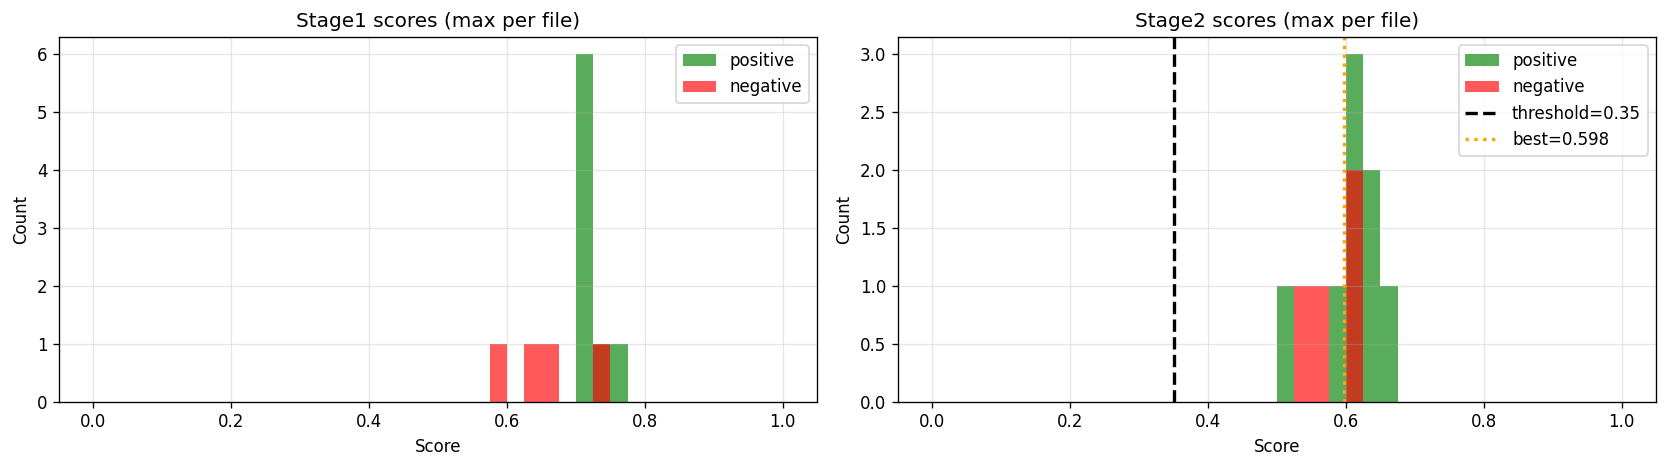

In [12]:
# ─── Score histograms ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col, title in [
    (axes[0], 'max_s1', 'Stage1 scores (max per file)'),
    (axes[1], 'max_s2', 'Stage2 scores (max per file)'),
]:
    pos_scores = pos_df[col].values
    neg_scores = neg_df[col].values
    bins = np.linspace(0, 1, 41)
    ax.hist(pos_scores, bins=bins, alpha=0.65, label='positive', color='green')
    ax.hist(neg_scores, bins=bins, alpha=0.65, label='negative', color='red')
    if col == 'max_s2':
        ax.axvline(STAGE2_THRESHOLD, color='black', lw=2, ls='--',
                   label=f'threshold={STAGE2_THRESHOLD}')
        ax.axvline(best_thr, color='orange', lw=2, ls=':',
                   label=f'best={best_thr:.3f}')
    ax.set_title(title); ax.set_xlabel('Score'); ax.set_ylabel('Count')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/score_histograms.png', bbox_inches='tight')
plt.show()

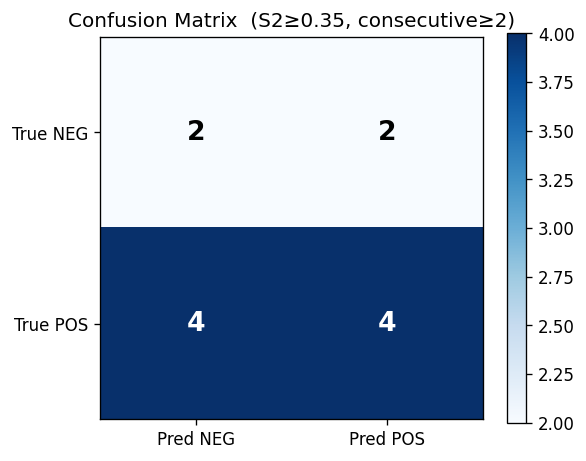

In [13]:
# ─── Confusion matrix ─────────────────────────────────────────────────────────
import matplotlib.patches as mpatches

cm = np.array([[tn, fp], [fn, tp]])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Pred NEG','Pred POS'])
ax.set_yticklabels(['True NEG','True POS'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=16, fontweight='bold')
ax.set_title(f'Confusion Matrix  (S2≥{STAGE2_THRESHOLD}, consecutive≥{STAGE2_CONSECUTIVE_REQUIRED})')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', bbox_inches='tight')
plt.show()

In [14]:
# ─── False Positives & False Negatives detail ─────────────────────────────────
print('── False Negatives (missed Hey M) ────────────────────────')
fn_df = pos_df[pos_df['detected'] == 0][['file','max_s1','max_s2','mean_s2','n_windows']]
if fn_df.empty:
    print('  ✅ None!')
else:
    print(fn_df.to_string(index=False))

print('\n── False Positives (wrong triggers) ──────────────────────')
fp_df = neg_df[neg_df['detected'] == 1][['file','max_s1','max_s2','mean_s2','n_windows']]
if fp_df.empty:
    print('  ✅ None!')
else:
    print(fp_df.to_string(index=False))

── False Negatives (missed Hey M) ────────────────────────
                                      file  max_s1  max_s2  mean_s2  n_windows
WhatsApp Ptt 2026-06-02 at 12.58.04 PM.ogg  0.7228  0.5195   0.5195          1
WhatsApp Ptt 2026-06-02 at 12.58.11 PM.ogg  0.7090  0.6313   0.6313          1
WhatsApp Ptt 2026-06-02 at 12.58.19 PM.ogg  0.7219  0.5977   0.5977          1
WhatsApp Ptt 2026-06-02 at 12.58.32 PM.ogg  0.7214  0.6007   0.6007          1

── False Positives (wrong triggers) ──────────────────────
                                     file  max_s1  max_s2  mean_s2  n_windows
WhatsApp Ptt 2026-06-02 at 1.00.04 PM.ogg  0.7456  0.6205   0.5942          2
WhatsApp Ptt 2026-06-02 at 1.00.11 PM.ogg  0.6685  0.6029   0.5821          2


In [15]:
# ─── Threshold recommendation ─────────────────────────────────────────────────
print('\n── Threshold sweep (single-window, consecutive=1) ────────')
print(f'{"Threshold":>10}  {"Recall":>8}  {"Precision":>10}  {"F1":>6}  {"FP":>4}')
for thr in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    pred = (s2_scores >= thr).astype(int)
    _tp = int(((pred == 1) & (y_true == 1)).sum())
    _fp = int(((pred == 1) & (y_true == 0)).sum())
    _fn = int(((pred == 0) & (y_true == 1)).sum())
    _r  = _tp / (_tp + _fn + 1e-9)
    _p  = _tp / (_tp + _fp + 1e-9)
    _f1 = 2*_p*_r / (_p + _r + 1e-9)
    marker = ' ← current' if abs(thr - STAGE2_THRESHOLD) < 0.005 else ''
    marker += ' ← best F1' if abs(thr - best_thr) < 0.03 else ''
    print(f'{thr:>10.2f}  {_r:>8.3f}  {_p:>10.3f}  {_f1:>6.3f}  {_fp:>4}{marker}')


── Threshold sweep (single-window, consecutive=1) ────────
 Threshold    Recall   Precision      F1    FP
      0.25     1.000       0.667   0.800     4
      0.30     1.000       0.667   0.800     4
      0.35     1.000       0.667   0.800     4 ← current
      0.40     1.000       0.667   0.800     4
      0.45     1.000       0.667   0.800     4
      0.50     1.000       0.667   0.800     4
      0.55     0.875       0.700   0.778     3
      0.60     0.750       0.750   0.750     2 ← best F1


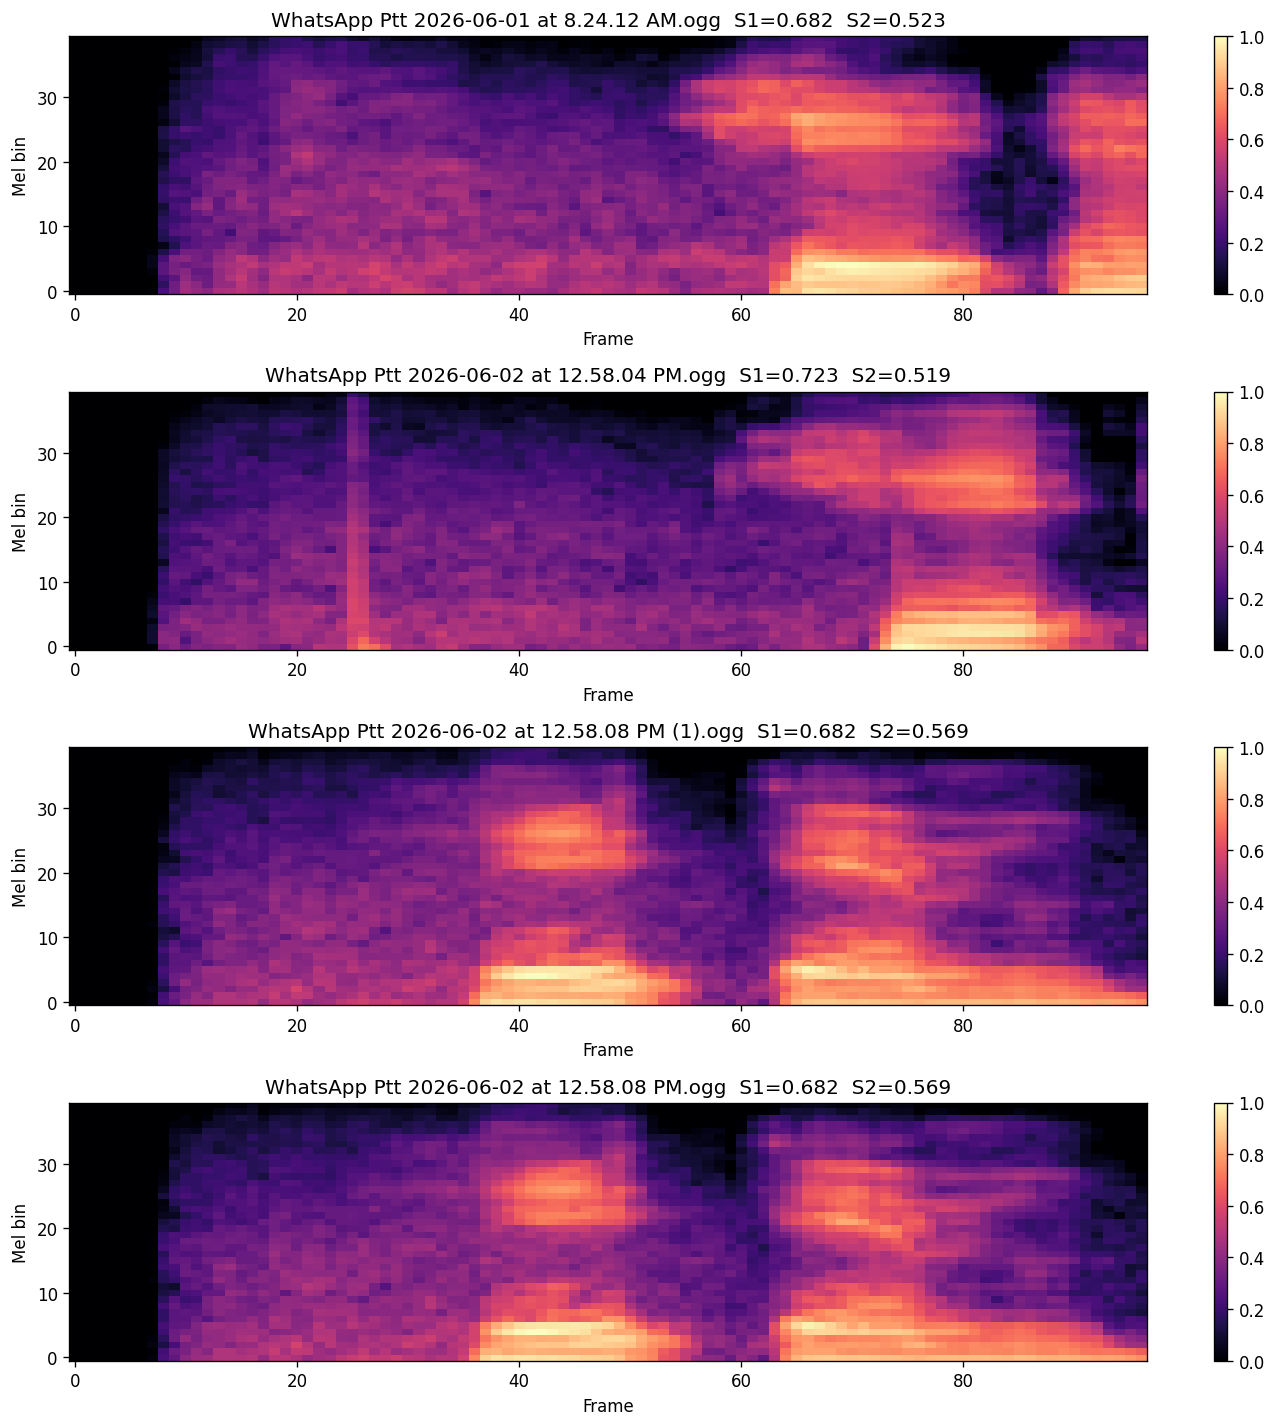

In [16]:
# ─── Visualise a few positive samples ─────────────────────────────────────────
n_show = min(4, len(pos_files))
if n_show > 0:
    fig, axes = plt.subplots(n_show, 1, figsize=(12, 3 * n_show))
    if n_show == 1: axes = [axes]
    for ax, fpath in zip(axes, pos_files[:n_show]):
        audio, _ = librosa.load(fpath, sr=SAMPLE_RATE, mono=True)
        chunk = audio[:FRAME_LENGTH]
        if len(chunk) < FRAME_LENGTH:
            chunk = np.pad(chunk, (0, FRAME_LENGTH - len(chunk)))
        mel = audio_to_mel(chunk)[0, :, :, 0]  # [40, 97]
        im = ax.imshow(mel, aspect='auto', origin='lower', cmap='magma')
        s1, s2 = infer_window(chunk)
        ax.set_title(f'{Path(fpath).name}  S1={s1:.3f}  S2={s2:.3f}')
        ax.set_ylabel('Mel bin'); ax.set_xlabel('Frame')
        plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig('/content/mel_samples.png', bbox_inches='tight')
    plt.show()

In [17]:
# ─── Export results CSV ────────────────────────────────────────────────────────
csv_path = '/content/eval_results.csv'
df.to_csv(csv_path, index=False)
print(f'Results saved → {csv_path}')

# Copy to Drive if available
try:
    drive_csv = Path(DRIVE_MODEL_DIR) / 'eval_results.csv'
    import shutil
    shutil.copy2(csv_path, str(drive_csv))
    print(f'Also saved → {drive_csv}')
except Exception as e:
    print(f'  (Drive copy skipped: {e})')

print('\n── Final Summary ─────────────────────────────────────────')
print(f'Files tested : {len(pos_files)} positives  {len(neg_files)} negatives')
print(f'Recall       : {recall:.3f}')
print(f'Precision    : {precision:.3f}')
print(f'F1           : {f1:.3f}')
print(f'Best S2 thr  : {best_thr:.3f}  (F1={best_f1:.3f})')
print(f'Average Precision (AP): {ap:.3f}')

Results saved → /content/eval_results.csv
Also saved → /content/drive/MyDrive/wakeword_checkpoint/eval_results.csv

── Final Summary ─────────────────────────────────────────
Files tested : 8 positives  4 negatives
Recall       : 0.500
Precision    : 0.667
F1           : 0.571
Best S2 thr  : 0.598  (F1=0.824)
Average Precision (AP): 0.858
